In [1]:
import os
os.environ['OMP_NUM_THREADS']      = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS']      = '1'

from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import pandas as pd
import numpy  as np
import json, os, joblib, math, datetime
from scipy import signal
pd.set_option('display.max_columns', None)

In [2]:
TEST    = json.loads(open('../../info.json', 'r').read()).get('test', 1)
SOURCE  = f'../../Dataset/test{TEST}/files/data.csv'
DATASET = 'Backup/target.csv'
RESULTS = f'../../Dataset/test{TEST}/results'

print('SOURCE:', SOURCE)

SOURCE: ../../Dataset/test1/files/data.csv


# IMPORTANDO DADOS
Saída do ensaio de pêndulo: cada amostra traz a IMU em teste (`target_`) e a MRU de referência (`ref_`) já alinhadas no mesmo instante.

In [3]:
df = pd.read_csv(SOURCE)
print(len(df), 'linhas')
df.head()

1801 linhas


,time,target_wz,target_tmp,target_pitch,target_e,target_ay,target_ax,target_wx,target_wy,target_az,target_roll,target_yaw,static,ref_sample_time,ref_wz,ref_pitch,ref_q0,ref_q1,ref_ay,ref_wx,ref_ax,ref_q2,ref_wy,ref_la_pos_mon_d,ref_az,ref_roll,ref_yaw,ref_q3
0,0.0,-6.92455,53.0,-1.525,-22.176,10.733555,0.194623,-47.92960,-1.16726,-0.614769,18.043,2.936,False,605000000.0,0.200478,0.304871,-0.8118,0.5835,9.59,-44.581846,0.06400,0.01196,0.471315,-0.5252,0.8262,-71.390541,2.771970,-0.02120
1,0.1,-8.13221,52.9,-0.742,-16.704,11.618576,0.294719,-58.13591,-1.05996,-0.532550,12.732,2.725,False,705000000.0,0.165413,0.337243,-0.7843,0.6199,10.54,-54.981030,0.09128,0.01243,0.546086,-0.4685,0.8149,-76.661753,2.723841,-0.02047
2,0.2,-8.42212,53.1,0.119,-10.440,12.899422,0.256924,-67.53252,-1.95110,-2.312996,6.586,2.578,False,805000000.0,0.189592,0.366750,-0.7505,0.6604,11.46,-62.337808,0.12330,0.01297,0.585563,-0.4231,0.7793,-82.677810,2.667691,-0.01959
3,0.3,-9.92099,53.3,1.010,-3.240,12.406766,0.425020,-67.39252,-1.05936,-0.455019,-0.016,2.655,False,905000000.0,0.310085,0.387721,-0.7116,0.7021,12.17,-66.291217,0.19090,0.01440,-1.635795,-0.3990,0.7029,-89.209529,2.743322,-0.01942
4,0.4,-9.44709,52.9,1.984,3.744,12.362390,0.271203,-66.62502,-1.97845,-0.208931,-6.779,2.656,False,5000000.0,0.653172,0.442381,-0.6696,0.7424,12.51,-66.806879,0.17590,0.01442,0.789536,-0.4016,0.5932,-95.913135,2.624720,-0.01821


# DEFASAGEM
- Atraso da IMU em teste contra a MRU de referência: pico da correlação cruzada do roll, só no trecho em movimento (`static` falso)
- Todas as colunas `target_` andam juntas, sem atravessar o buraco da gravação; as amostras que ficam sem par saem

In [4]:
# ATRASO DA IMU EM TESTE CONTRA A REFERÊNCIA PELO PICO DA CORRELAÇÃO CRUZADA
class Phaser:
    def __init__(self, target, reference):
        self.target    = target
        self.reference = reference

    def get(self, df, var):
        if df.empty:
            return 0

        x = df[self.target + var]
        y = df[self.reference + var]

        correlation = np.correlate(y - y.mean(), x - x.mean(), mode='full')
        lags = np.arange(-len(df) + 1, len(df))
        return lags[np.argmax(correlation)]

    def set(self, df, lag):
        columns = df.filter(regex=f'^{self.target}').columns
        step    = df.time.diff()
        block   = (step > 1.5*step.median()).cumsum()    # O DESLOCAMENTO NÃO ATRAVESSA O BURACO DA GRAVAÇÃO

        df[columns] = df.groupby(block)[columns].shift(lag)
        return df.dropna(subset=columns).reset_index(drop=True)


phaser = Phaser('target_', 'ref_')
lag    = phaser.get(df[~df.static], 'roll')
df     = phaser.set(df, lag)
print('defasagem:', lag, 'amostras |', len(df), 'linhas')

defasagem: 0 amostras | 1801 linhas


# RENOMEANDO COLUNAS

In [5]:
SENSORS = ['ax', 'ay', 'az', 'wx', 'wy', 'wz']
ANGLES  = ['pitch', 'roll', 'yaw']

# ENTRADA SAI DA IMU EM TESTE, RÓTULO SAI DA MRU DE REFERÊNCIA
columns = {f'target_{var}': var for var in SENSORS} | {f'ref_{var}': var for var in ANGLES}
df = df[['time', 'static'] + list(columns)].rename(columns=columns)
df

,time,static,ax,ay,az,wx,wy,wz,pitch,roll,yaw
0,0.0,False,0.194623,10.733555,-0.614769,-47.92960,-1.16726,-6.92455,0.304871,-71.390541,2.771970
1,0.1,False,0.294719,11.618576,-0.532550,-58.13591,-1.05996,-8.13221,0.337243,-76.661753,2.723841
2,0.2,False,0.256924,12.899422,-2.312996,-67.53252,-1.95110,-8.42212,0.366750,-82.677810,2.667691
3,0.3,False,0.425020,12.406766,-0.455019,-67.39252,-1.05936,-9.92099,0.387721,-89.209529,2.743322
4,0.4,False,0.271203,12.362390,-0.208931,-66.62502,-1.97845,-9.44709,0.442381,-95.913135,2.624720
...,...,...,...,...,...,...,...,...,...,...,...
1796,279.5,True,0.235938,9.717615,-0.402014,-0.09929,-0.03678,-0.00493,1.645535,-92.131613,6.371291
1797,279.6,True,0.257170,9.768983,-0.404622,-0.18597,0.40111,0.50338,1.644962,-92.131613,6.371291
1798,279.7,True,0.266545,9.796167,-0.485586,0.06592,-0.14609,0.14588,1.645535,-92.131613,6.377020
1799,279.8,True,0.222170,9.755871,-0.409330,-0.01801,-0.00522,0.04660,1.644962,-92.131613,6.377020


# PERÍODO DE AMOSTRAGEM
- Verificando a distribuição do período para verificar número de outliers

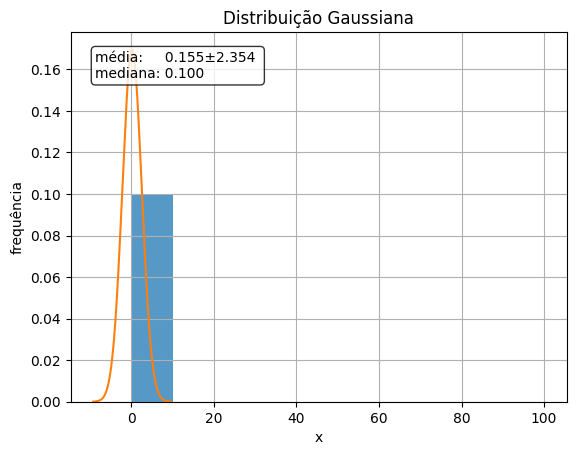

2799 amostras na grade de 0.1 s


,time,static,ax,ay,az,wx,wy,wz,pitch,roll,yaw
0,0.0,False,0.194623,10.733555,-0.614769,-47.92960,-1.16726,-6.92455,0.304871,-71.390541,2.771970
1,0.1,False,0.294719,11.618576,-0.532550,-58.13591,-1.05996,-8.13221,0.337243,-76.661753,2.723841
2,0.2,False,0.256924,12.899422,-2.312996,-67.53252,-1.95110,-8.42212,0.366750,-82.677810,2.667691
3,0.3,False,0.425020,12.406766,-0.455019,-67.39252,-1.05936,-9.92099,0.387721,-89.209529,2.743322
4,0.4,False,0.271203,12.362390,-0.208931,-66.62502,-1.97845,-9.44709,0.442381,-95.913135,2.624720
...,...,...,...,...,...,...,...,...,...,...,...
2794,279.4,True,0.269369,9.760873,-0.416959,-0.09321,0.25104,-0.21920,1.644962,-92.131613,6.371291
2795,279.5,True,0.235938,9.717615,-0.402014,-0.09929,-0.03678,-0.00493,1.645535,-92.131613,6.371291
2796,279.6,True,0.257170,9.768983,-0.404622,-0.18597,0.40111,0.50338,1.644962,-92.131613,6.371291
2797,279.7,True,0.266545,9.796167,-0.485586,0.06592,-0.14609,0.14588,1.645535,-92.131613,6.377020


In [6]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)

    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

# GRADE E LEITURAS ARREDONDADAS NA MESMA CASA: SEM ISSO O RUÍDO DE FLOAT (1e-14) FAZ O merge_asof SEGURAR A AMOSTRA ANTERIOR
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = (df[key] - df[key].iloc[0]).round(10)

    n = int(np.floor(df[key].iloc[-1] / dt)) + 1
    newAxis = np.round(np.linspace(0, dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    return pd.merge_asof(target, df, on=key, direction='backward')


time = df.time.diff()[1:].to_numpy()
dt   = 0.1

gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
print(len(df), 'amostras na grade de', dt, 's')
df

# SALVANDO DADOS

In [7]:
os.makedirs('Backup', exist_ok=True)

df.to_csv(DATASET, index=None)
pd.read_csv(DATASET).head()

,time,static,ax,ay,az,wx,wy,wz,pitch,roll,yaw
0,0.0,False,0.194623,10.733555,-0.614769,-47.92960,-1.16726,-6.92455,0.304871,-71.390541,2.771970
1,0.1,False,0.294719,11.618576,-0.532550,-58.13591,-1.05996,-8.13221,0.337243,-76.661753,2.723841
2,0.2,False,0.256924,12.899422,-2.312996,-67.53252,-1.95110,-8.42212,0.366750,-82.677810,2.667691
3,0.3,False,0.425020,12.406766,-0.455019,-67.39252,-1.05936,-9.92099,0.387721,-89.209529,2.743322
4,0.4,False,0.271203,12.362390,-0.208931,-66.62502,-1.97845,-9.44709,0.442381,-95.913135,2.624720


# VISUALIZAÇÃO DOS DADOS

In [8]:
xCols  = SENSORS
yCols  = ANGLES
LIMITS = (0, 60)

df = df[(df[xCols].diff() != 0).any(axis=1)].reset_index(drop=True)    # FORA O BURACO QUE A GRADE PREENCHEU: O GIRO REPETIDO VIRAVA 1216° DE ROTAÇÃO

print(f'dt {dt} s | {len(df)} amostras | {df.static.sum()} paradas | buraco de {df.time.diff().max():.0f} s')
df

dt 0.1 s | 1800 amostras | 1000 paradas | buraco de 100 s


,time,static,ax,ay,az,wx,wy,wz,pitch,roll,yaw
0,0.0,False,0.194623,10.733555,-0.614769,-47.92960,-1.16726,-6.92455,0.304871,-71.390541,2.771970
1,0.1,False,0.294719,11.618576,-0.532550,-58.13591,-1.05996,-8.13221,0.337243,-76.661753,2.723841
2,0.2,False,0.256924,12.899422,-2.312996,-67.53252,-1.95110,-8.42212,0.366750,-82.677810,2.667691
3,0.3,False,0.425020,12.406766,-0.455019,-67.39252,-1.05936,-9.92099,0.387721,-89.209529,2.743322
4,0.4,False,0.271203,12.362390,-0.208931,-66.62502,-1.97845,-9.44709,0.442381,-95.913135,2.624720
...,...,...,...,...,...,...,...,...,...,...,...
1795,279.4,True,0.269369,9.760873,-0.416959,-0.09321,0.25104,-0.21920,1.644962,-92.131613,6.371291
1796,279.5,True,0.235938,9.717615,-0.402014,-0.09929,-0.03678,-0.00493,1.645535,-92.131613,6.371291
1797,279.6,True,0.257170,9.768983,-0.404622,-0.18597,0.40111,0.50338,1.644962,-92.131613,6.371291
1798,279.7,True,0.266545,9.796167,-0.485586,0.06592,-0.14609,0.14588,1.645535,-92.131613,6.377020


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    1800 non-null   float64
 1   static  1800 non-null   bool   
 2   ax      1800 non-null   float64
 3   ay      1800 non-null   float64
 4   az      1800 non-null   float64
 5   wx      1800 non-null   float64
 6   wy      1800 non-null   float64
 7   wz      1800 non-null   float64
 8   pitch   1800 non-null   float64
 9   roll    1800 non-null   float64
 10  yaw     1800 non-null   float64
dtypes: bool(1), float64(10)
memory usage: 142.5 KB


In [10]:
df.describe()

,time,ax,ay,az,wx,wy,wz,pitch,roll,yaw
count,1800.00000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,145.45000,0.233662,9.887098,-0.414362,-0.110539,0.010999,-0.007866,1.160627,-92.115475,4.625742
std,98.02825,0.068377,0.453528,0.165811,18.323658,0.443921,2.617892,0.504132,7.774347,1.333315
min,0.00000,-0.935613,8.169606,-2.312996,-67.532520,-1.978450,-9.920990,0.170913,-120.951391,2.299280
25%,44.97500,0.211480,9.752412,-0.453070,-0.347303,-0.193785,-0.378135,0.660620,-92.188909,3.267005
50%,189.85000,0.232320,9.780049,-0.427295,-0.000365,0.010835,0.006265,1.553862,-92.188909,5.277228
75%,234.82500,0.252730,9.855276,-0.396993,0.362387,0.218927,0.398352,1.611301,-92.131613,5.844170
max,279.80000,1.235275,14.390033,1.375491,66.068610,3.193530,11.926620,1.645535,-64.629639,6.377020


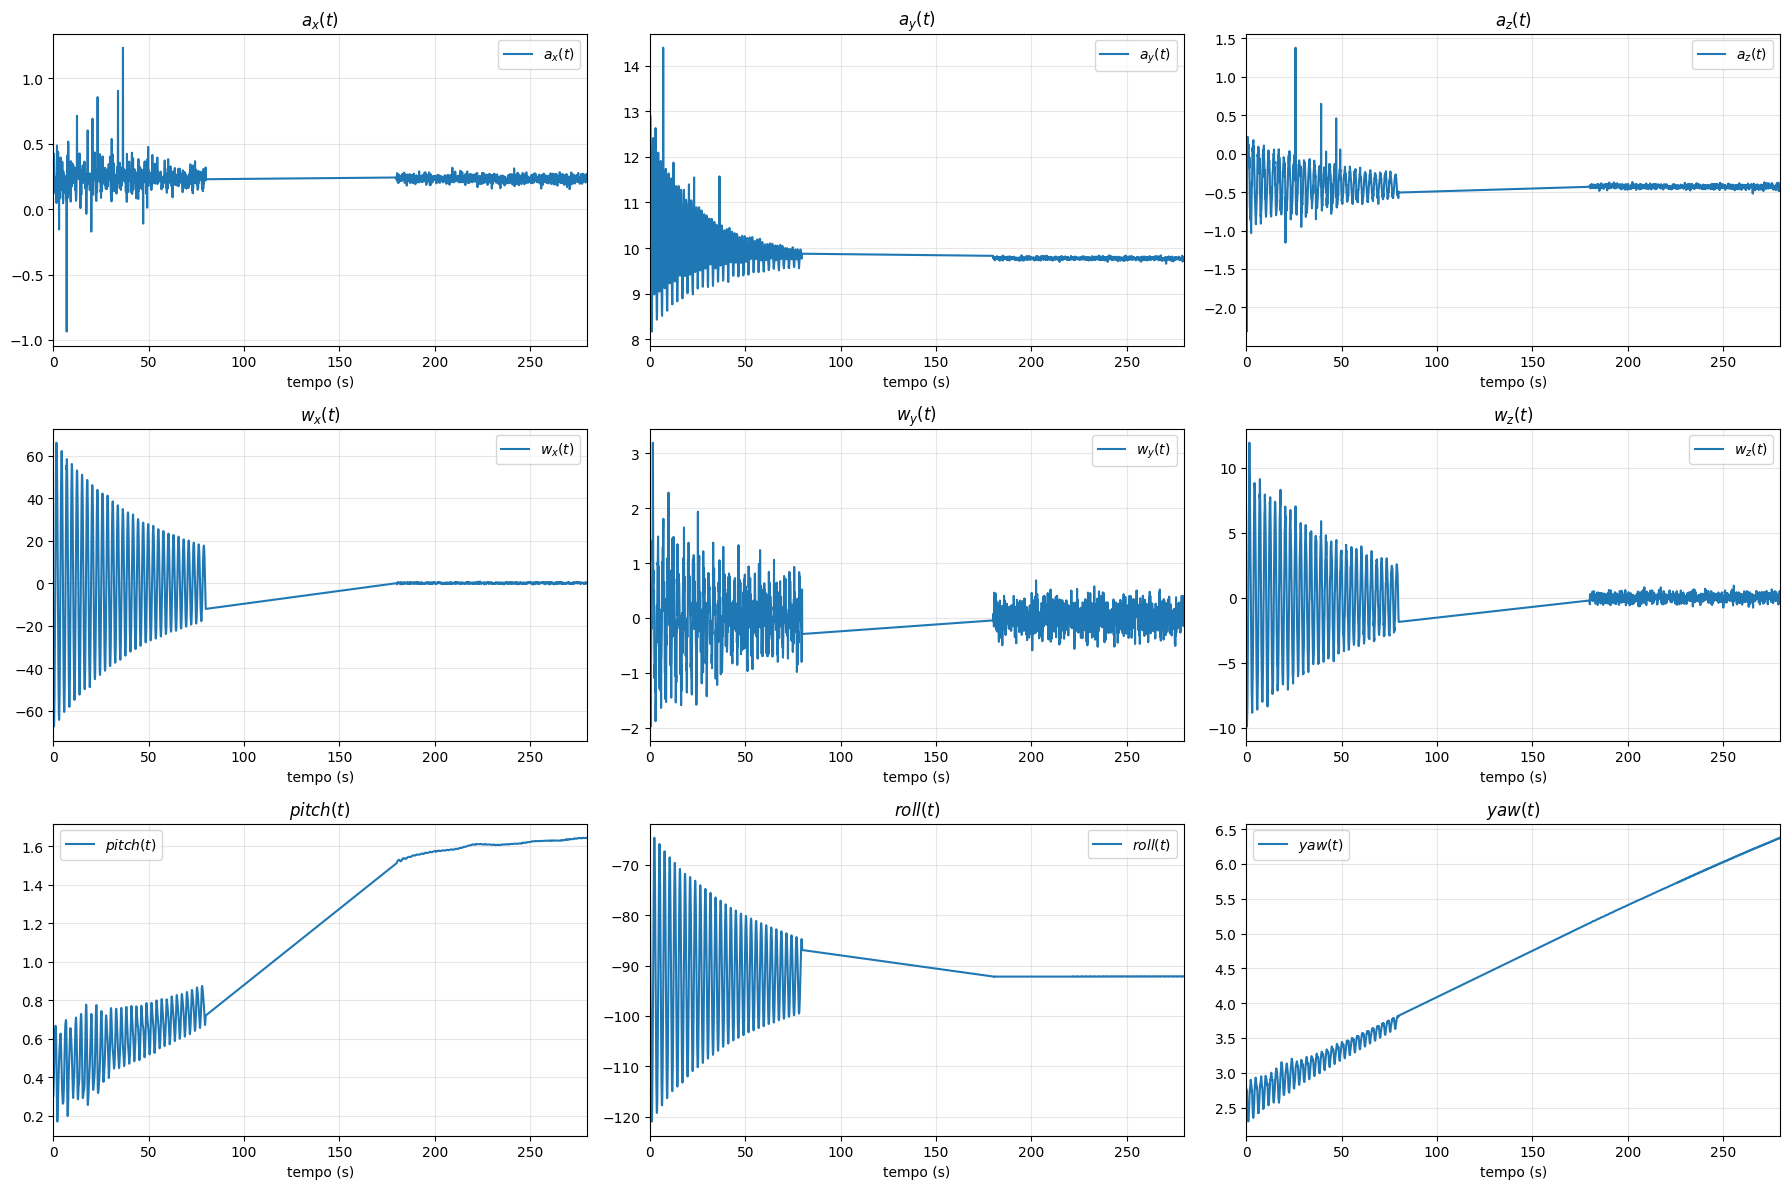

In [11]:
# GRADE DE SUBPLOTS RECORTADA POR FRAÇÃO DO TEMPO TOTAL
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = (t_max - t_min)

    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])

    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)

        plt.subplot(numRows, numCols, i+1)
        plt.plot(time[mask], values[mask], label=key)

        plt.xlim(start_time, end_time)
        if yLim: plt.ylim(yLim)
        plt.title(key); plt.xlabel('tempo (s)')
        plt.grid(alpha=0.3); plt.legend()

    plt.tight_layout()
    plt.show()


# PAINEL PADRÃO: GIROSCÓPIO, ACELERÔMETRO E ATITUDE DE REFERÊNCIA
def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# FILTRO DE KALMAN

Estado nominal: quaternion $q$ do corpo para a navegação (referencial com gravidade em $-z$, como o da
referência) e bias do giroscópio $b$. O erro é **multiplicativo**, $q_{real} = q \otimes \delta q(\delta\theta)$,
então quem entra na covariância é só $\delta x = [\,\delta\theta,\ \delta b\,] \in \mathbb{R}^6$: o quaternion
nunca é linearizado e não existe singularidade de Euler dentro do filtro.

**Propagação.** $q \leftarrow q \otimes \exp\big(\tfrac{1}{2}(\omega - b)\,\Delta t\big)$ com a exponencial
exata — a 10 Hz o passo chega a 7°, ângulo em que o seno já não pode ser linearizado. A dinâmica do erro é
$\dot{\delta\theta} = -[\omega\times]\delta\theta - \delta b$ e $\dot{\delta b} = 0$, cuja transição discreta é

$$\Phi = \begin{bmatrix} e^{-[\omega\times]\Delta t} & -\int_0^{\Delta t} e^{-[\omega\times]s}\,ds \\[2pt] 0 & I \end{bmatrix}$$

com $e^{-[\omega\times]\Delta t} = R(\omega\Delta t)^\top$ calculado do próprio incremento de quaternion. O ruído
discretizado (Farrell) carrega o termo cruzado, que é o que faz o bias convergir:
$Q_{\theta\theta} = \sigma_g^2 \Delta t + \sigma_b^2 \Delta t^3/3$, $Q_{\theta b} = -\sigma_b^2 \Delta t^2/2$,
$Q_{bb} = \sigma_b^2 \Delta t$.

**Correção do acelerômetro.** A medida é o versor $z = a/\lVert a \rVert$ e a predição $h = R^\top [0,0,-1]$.
Linearizando em torno do nominal, $z - h = [h\times]\,\delta\theta$, logo $H = [\,[h\times]\ \ 0\,]$. O posto de
$H$ é 2: a rotação em torno de $h$ — a proa — **não é observável sem magnetômetro**, e é por isso que $yaw_0$
entra como condição inicial e não como algo que o acelerômetro conserta.

**Braço de alavanca.** Num pêndulo o acelerômetro não mede só gravidade:

$$f = R^\top(-g) + \omega \times (\omega \times r) + \dot\omega \times r$$

Sem descontar os dois últimos termos o nivelamento erra ~9° durante o balanço; com $r$ estimado o erro cai para
~1,3°. Com $r = 0$ o modelo volta a ser o clássico, então nada se perde num sensor que não gira em torno de um
ponto externo.

**ZARU.** Nas janelas paradas a taxa verdadeira é zero: $z = \omega$, $h = b$, $H = [\,0\ \ I\,]$. Observa os
três eixos do bias, inclusive o vertical — o único jeito de segurar a deriva de proa sem magnetômetro.

**Joseph.** $P = (I-KH)P(I-KH)^\top + KRK^\top$ mantém $P$ simétrica e positiva definida ao longo de milhares
de correções, coisa que a forma $(I-KH)P$ não garante em ponto flutuante.

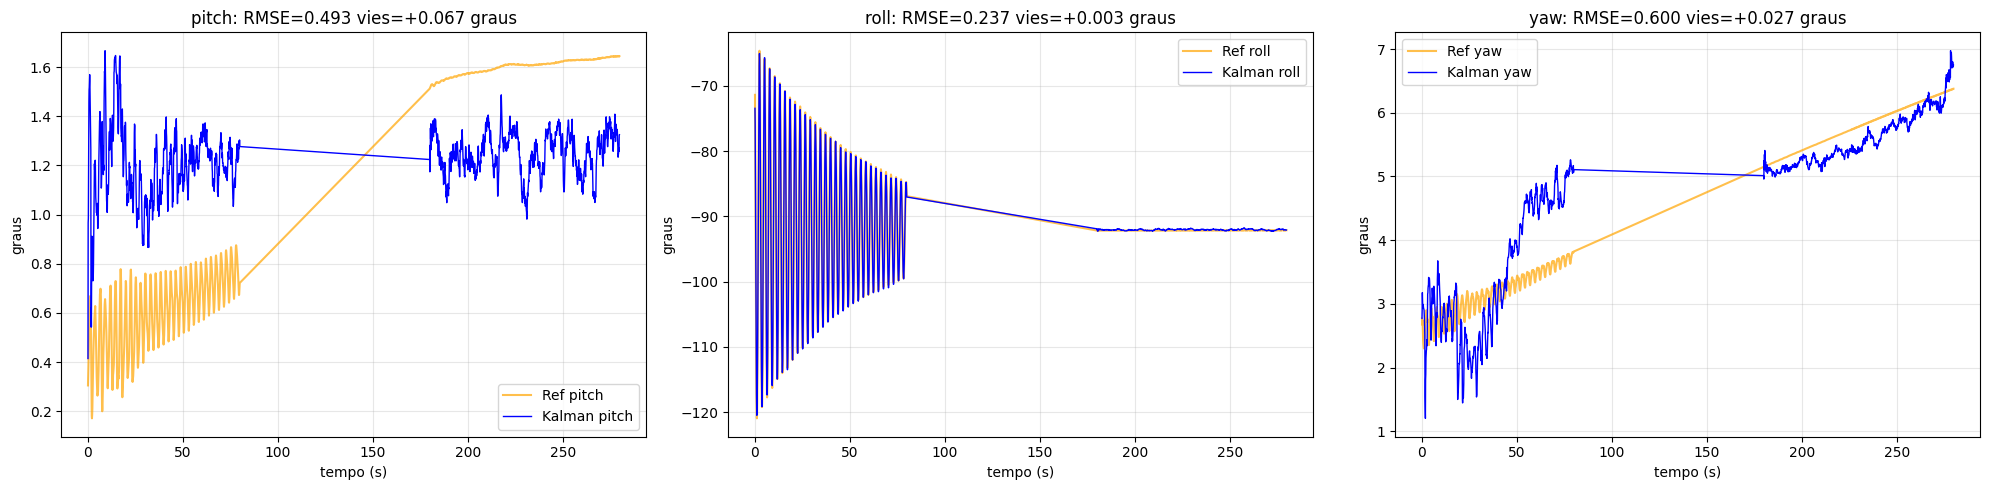

In [12]:
class KalmanFilter:
    NAV_GRAVITY = np.array([0.0, 0.0, -1.0])   # FORCA ESPECIFICA EM REPOUSO, NORMALIZADA
    TILT_P0     = 1.0                          # (rad^2) ATITUDE INICIAL DESCONHECIDA: DEIXA O ACCEL PUXAR
    BIAS_P0     = 1e-4                         # (rad/s)^2 BIAS INICIAL TIPICO DE UM MEMS JA COMPENSADO
    GAP_FACTOR  = 3.0                          # ACIMA DISSO O INTERVALO E BURACO DE AQUISICAO, NAO AMOSTRA
    STILL_ACCEL = 0.20                         # (m/s^2) TOLERANCIA DE |a|-g NO DETECTOR DE REPOUSO
    STILL_GYRO  = math.radians(1.0)            # (rad/s) TOLERANCIA DE |w| NO DETECTOR DE REPOUSO

    def __init__(self, df, xCols, yCols, params=None):
        self.df     = df.reset_index(drop=True).copy()
        self.xCols  = xCols
        self.yCols  = yCols
        self.params = params or {}

        p = self.params
        self.g          = p.get('g', 9.81)             # GRAVIDADE LOCAL (m/s^2), CENTRO DO GATE DO ACCEL
        self.gyroNoise  = 10 ** p.get('gyroNoise',  -6.0)   # log10 DA DENSIDADE DE RUIDO DO GIRO, (rad/s)^2/Hz
        self.biasNoise  = 10 ** p.get('biasNoise', -12.0)   # log10 DO RANDOM WALK DO BIAS, (rad/s^2)^2/Hz
        self.accelNoise = 10 ** p.get('accelNoise', -3.0)   # log10 DA VARIANCIA DO VERSOR DO ACELEROMETRO
        self.zuptNoise  = 10 ** p.get('zuptNoise',  -6.0)   # log10 DA VARIANCIA DO ZARU, (rad/s)^2
        self.accelGateK = 10 ** p.get('accelGateK',  1.0)   # log10 DO GANHO QUE INFLA R QUANDO |a| FOGE DE g
        self.align      = np.array([p.get('alignX', 0.0), p.get('alignY', 0.0), p.get('alignZ', 0.0)])
        self.lever      = np.array([p.get('leverX', 0.0), p.get('leverY', 0.0), p.get('leverZ', 0.0)])
        self.yaw0       = p.get('yaw0')                # PROA INICIAL (graus); None PEGA A DA REFERENCIA
        self.gyroPhase  = p.get('gyroPhase', 0.5)      # FASE DA TAXA INTEGRADA: 0 RETANGULAR, 0.5 TRAPEZOIDAL

    # PRODUTO DE HAMILTON ENTRE DOIS QUATERNIONS (w, x, y, z)
    def quatMul(self, q1, q2):
        w1, x1, y1, z1 = q1
        w2, x2, y2, z2 = q2
        return np.array([
            w1*w2 - x1*x2 - y1*y2 - z1*z2,
            w1*x2 + x1*w2 + y1*z2 - z1*y2,
            w1*y2 - x1*z2 + y1*w2 + z1*x2,
            w1*z2 + x1*y2 - y1*x2 + z1*w2,
        ])

    # EXPONENCIAL EXATA DO VETOR DE ROTACAO: A 10 Hz O PASSO CHEGA A 7 graus, ONDE O SENO JA NAO E LINEAR
    def quatFromRotVec(self, rotVec):
        angle = float(np.linalg.norm(rotVec))
        if angle < 1e-12:
            return np.array([1.0, *(rotVec / 2.0)])
        return np.array([math.cos(angle/2), *(rotVec / angle * math.sin(angle/2))])

    # MATRIZ DE ROTACAO CORPO -> NAVEGACAO (CONVENCAO DE HAMILTON, v_nav = R @ v_corpo)
    def quatToDCM(self, q):
        w, x, y, z = q
        return np.array([
            [1-2*(y*y+z*z), 2*(x*y-w*z),   2*(x*z+w*y)],
            [2*(x*y+w*z),   1-2*(x*x+z*z), 2*(y*z-w*x)],
            [2*(x*z-w*y),   2*(y*z+w*x),   1-2*(x*x+y*y)],
        ])

    # MATRIZ ANTISSIMETRICA (v x)
    def skew(self, v):
        return np.array([
            [0, -v[2], v[1]],
            [v[2], 0, -v[0]],
            [-v[1], v[0], 0],
        ])

    # NIVELAMENTO PELO ACELEROMETRO: u = R.T @ [0,0,-1] DA rolagem E arfagem; A PROA VEM DE FORA
    def initQuat(self, u, yaw):
        roll  = math.atan2(-u[1], -u[2])
        pitch = math.atan2(u[0], math.hypot(u[1], u[2]))
        x, y, z, w = Rotation.from_euler('xyz', [roll, pitch, math.radians(yaw)]).as_quat()
        return np.array([w, x, y, z])

    # PROPAGA ATITUDE E BIAS; dtQ E O TEMPO REAL DECORRIDO, dt O INTEGRADO (LIMITADO EM BURACOS)
    def predict(self, q, b, P, gyro, dt, dtQ):
        w  = gyro - b
        dq = self.quatFromRotVec(w * dt)
        q  = self.quatMul(q, dq)
        q /= np.linalg.norm(q)

        S = self.skew(w)
        F = np.eye(6)
        F[:3, :3] = self.quatToDCM(dq).T                                  # exp(-[w x] dt) EXATO
        F[:3, 3:] = -(np.eye(3)*dt - S*dt**2/2 + S@S*dt**3/6)             # -integral de exp(-[w x] s) ds

        sg, sb, I = self.gyroNoise, self.biasNoise, np.eye(3)
        Q = np.zeros((6, 6))
        Q[:3, :3] = I * (sg*dtQ + sb*dtQ**3/3)
        Q[:3, 3:] = Q[3:, :3] = I * (-sb*dtQ**2/2)            # o termo cruzado e o que faz o bias convergir
        Q[3:, 3:] = I * (sb*dtQ)
        return q, b, F @ P @ F.T + Q

    # CORRECAO MULTIPLICATIVA (MEKF): injeta o erro linearizado [dTheta, dBias] no estado nominal
    def correct(self, q, b, P, H, innovation, R):
        K  = P @ H.T @ np.linalg.inv(H @ P @ H.T + R)
        dx = K @ innovation

        q  = self.quatMul(q, self.quatFromRotVec(dx[:3]))
        q /= np.linalg.norm(q)

        A = np.eye(6) - K @ H
        P = A @ P @ A.T + K @ R @ K.T                         # forma de Joseph, robusta a erro numerico
        return q, b + dx[3:], (P + P.T) / 2

    # ROTACAO FIXA DE MONTAGEM DO SENSOR PARA O REFERENCIAL DA REFERENCIA
    def process(self, data):
        return data @ Rotation.from_euler('xyz', self.align, degrees=True).as_matrix()

    # JANELAS PARADAS: USA A COLUNA static SE EXISTIR, SENAO DETECTA POR NORMA DE ACCEL E GIRO
    def ready(self, accel, gyro):
        if 'static' in self.df:
            return self.df.static.to_numpy().astype(bool)
        quiet = np.abs(np.linalg.norm(accel, axis=1) - self.g) < self.STILL_ACCEL
        return quiet & (np.linalg.norm(gyro, axis=1) < self.STILL_GYRO)

    # RODA O FILTRO AMOSTRA A AMOSTRA E GUARDA QUATERNIONS, ANGULOS E BIAS
    def update(self):
        ax, ay, az, wx, wy, wz = self.xCols
        accel = self.process(self.df[[ax, ay, az]].to_numpy())
        gyro  = self.process(np.radians(self.df[[wx, wy, wz]].to_numpy()))

        time  = self.df.time.to_numpy()
        dtNom = float(np.median(np.diff(time))) if len(time) > 1 else 1.0
        dtQ = np.diff(time, prepend=time[0])               # a primeira so inicializa: nada decorreu antes
        gap = dtQ > self.GAP_FACTOR * dtNom
        dt  = np.minimum(dtQ, self.GAP_FACTOR * dtNom)

        alpha      = np.zeros_like(gyro)
        alpha[1:]  = np.diff(gyro, axis=0) / dtQ[1:, None]
        alpha[gap] = 0.0
        alpha[0]   = alpha[1] if len(alpha) > 1 else 0.0    # sem anterior ela entraria sem o termo tangencial
        rate       = gyro.copy()                            # a marca do giro nao cai no meio do passo
        rate[1:]   = gyro[1:] - self.gyroPhase * (gyro[1:] - gyro[:-1])
        rate[gap]  = gyro[gap]
        lever      = np.array([(self.skew(w) @ self.skew(w) + self.skew(a)) @ self.lever
                                 for w, a in zip(gyro, alpha)])
        accel  = accel - lever                          # tira a aceleracao do braco de alavanca
        norm   = np.linalg.norm(accel, axis=1)
        gate   = 1 + self.accelGateK * ((norm - self.g) / self.g) ** 2
        static = self.ready(accel, gyro)

        yaw = self.yaw0 if self.yaw0 is not None else float(self.df[self.yCols[2]].iloc[0])
        up  = accel[0] / norm[0] if norm[0] > 1e-6 else self.NAV_GRAVITY   # sem leitura util, comeca nivelado
        q   = self.initQuat(up, yaw)
        b   = np.zeros(3)
        P   = np.diag([self.TILT_P0]*3 + [self.BIAS_P0]*3)

        quats = np.zeros((len(self.df), 4))
        for i in range(len(self.df)):
            q, b, P = self.predict(q, b, P, rate[i], dt[i], dtQ[i])

            if gap[i]:
                P[:3, :3] = np.eye(3) * self.TILT_P0   # buraco: so o accel reancora a atitude

            if norm[i] > 1e-6:
                h = -self.quatToDCM(q)[2]              # R.T @ [0,0,-1] e menos a 3a linha
                H = np.zeros((3, 6))
                H[:, :3] = self.skew(h)
                q, b, P  = self.correct(q, b, P, H, accel[i]/norm[i] - h, self.accelNoise * gate[i] * np.eye(3))

            if static[i]:
                H = np.zeros((3, 6))
                H[:, 3:] = np.eye(3)
                q, b, P  = self.correct(q, b, P, H, gyro[i] - b, self.zuptNoise * np.eye(3))

            quats[i] = q

        euler = Rotation.from_quat(quats[:, [1, 2, 3, 0]]).as_euler('xyz', degrees=True)
        euler = np.degrees(np.unwrap(np.radians(euler), axis=0))   # continuidade em +-180, sem saltos

        self.quats  = quats
        self.bias   = np.degrees(b)
        self.euler  = euler
        self.result = self.df.copy()

        for k, name in enumerate(['roll', 'pitch', 'yaw']):
            self.result[f'kalman_{name}'] = euler[:, k]

    # DIFERENCA ANGULAR NO RAMO CURTO: SEM ISSO UM SALTO DE 360 VIRA ERRO DE 360
    def error(self, name, refCol):
        return (self.result[f'kalman_{name}'].to_numpy() - self.result[refCol].to_numpy() + 180) % 360 - 180

    def get(self):
        data = {}
        for name, refCol in zip(['pitch', 'roll', 'yaw'], self.yCols):
            err  = self.error(name, refCol)
            corr = np.corrcoef(self.result[f'kalman_{name}'], self.result[refCol])[0, 1]
            rmse = float(np.sqrt(np.mean(err**2)))
            data[refCol] = {'rmse': rmse, 'bias': float(np.mean(err)), 'corr': float(corr)}
        return data

    def info(self):
        return {'bias': self.bias.round(4).tolist(), **{k: round(v['rmse'], 4) for k, v in self.get().items()}}

    def plot(self, xlim=None, save=None):
        plt.figure(figsize=(20, 5))

        for i, (name, refCol) in enumerate(zip(['pitch', 'roll', 'yaw'], self.yCols)):
            err = self.error(name, refCol)
            plt.subplot(1, 3, i + 1)
            plt.plot(self.result.time, self.result[refCol], label=f'Ref {refCol}', color='orange', alpha=.7)
            plt.plot(self.result.time, self.result[f'kalman_{name}'], label=f'Kalman {name}', color='blue', linewidth=1)
            plt.title(f'{refCol}: RMSE={np.sqrt(np.mean(err**2)):.3f} vies={np.mean(err):+.3f} graus')
            plt.xlabel('tempo (s)'); plt.ylabel('graus'); plt.grid(alpha=.3); plt.legend()
            if xlim is not None: plt.xlim(xlim)

        plt.tight_layout()
        if save: plt.savefig(save, dpi=110, bbox_inches='tight')
        plt.show()


kf = KalmanFilter(df, xCols=xCols, yCols=yCols, params={
    'gyroNoise' :    -3.243099,
    'biasNoise' :   -14.169008,
    'accelNoise':    -1.510183,
    'zuptNoise' :     0.803745,
    'accelGateK':     3.869210,
    'alignX'    :    -4.796618,
    'alignY'    :    -8.415465,
    'alignZ'    :     0.196467,
    'leverX'    :     1.871451,
    'leverY'    :    -1.735827,
    'leverZ'    :     0.151919,
    'gyroPhase' :     0.480341,
})
kf.update()
kf.plot()

# OTIMIZAÇÃO DOS PARÂMETROS

As quatro covariâncias e o ganho do gate entram em **log10**: elas variam por décadas, e a CMA-ES usa um passo
inicial único, $\sigma_0 = 0{,}3\,\overline{(sup - inf)}$, para todas as dimensões — com limites lineares de
$10^{-12}$ a $10^{-1}$ ela nunca visitaria a região certa. Em log10 todas as caixas ficam com largura
comparável (10 a 30), que é a condição para o passo isotrópico inicial fazer sentido.

`g` fica de fora da busca: ele só centra o gate e sai direto da norma do acelerômetro em repouso
(9,785 m/s² aqui). Gastar uma dimensão de largura 0,2 numa caixa onde as outras têm largura 10 estragaria o
$\sigma_0$ de todo mundo.

genetic:   0%|          | 0/3000 [00:00<?, ?ev/s]

genetic: 100%|██████████| 2985/2985 [01:19<00:00, 37.62ev/s, best=0.988521, pop=15]
soma de RMSE: 0.9885 graus


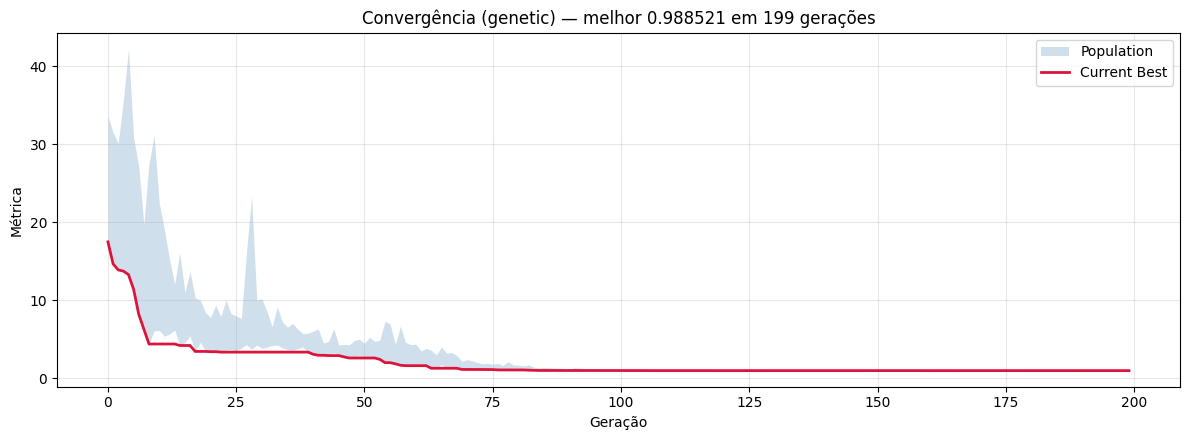

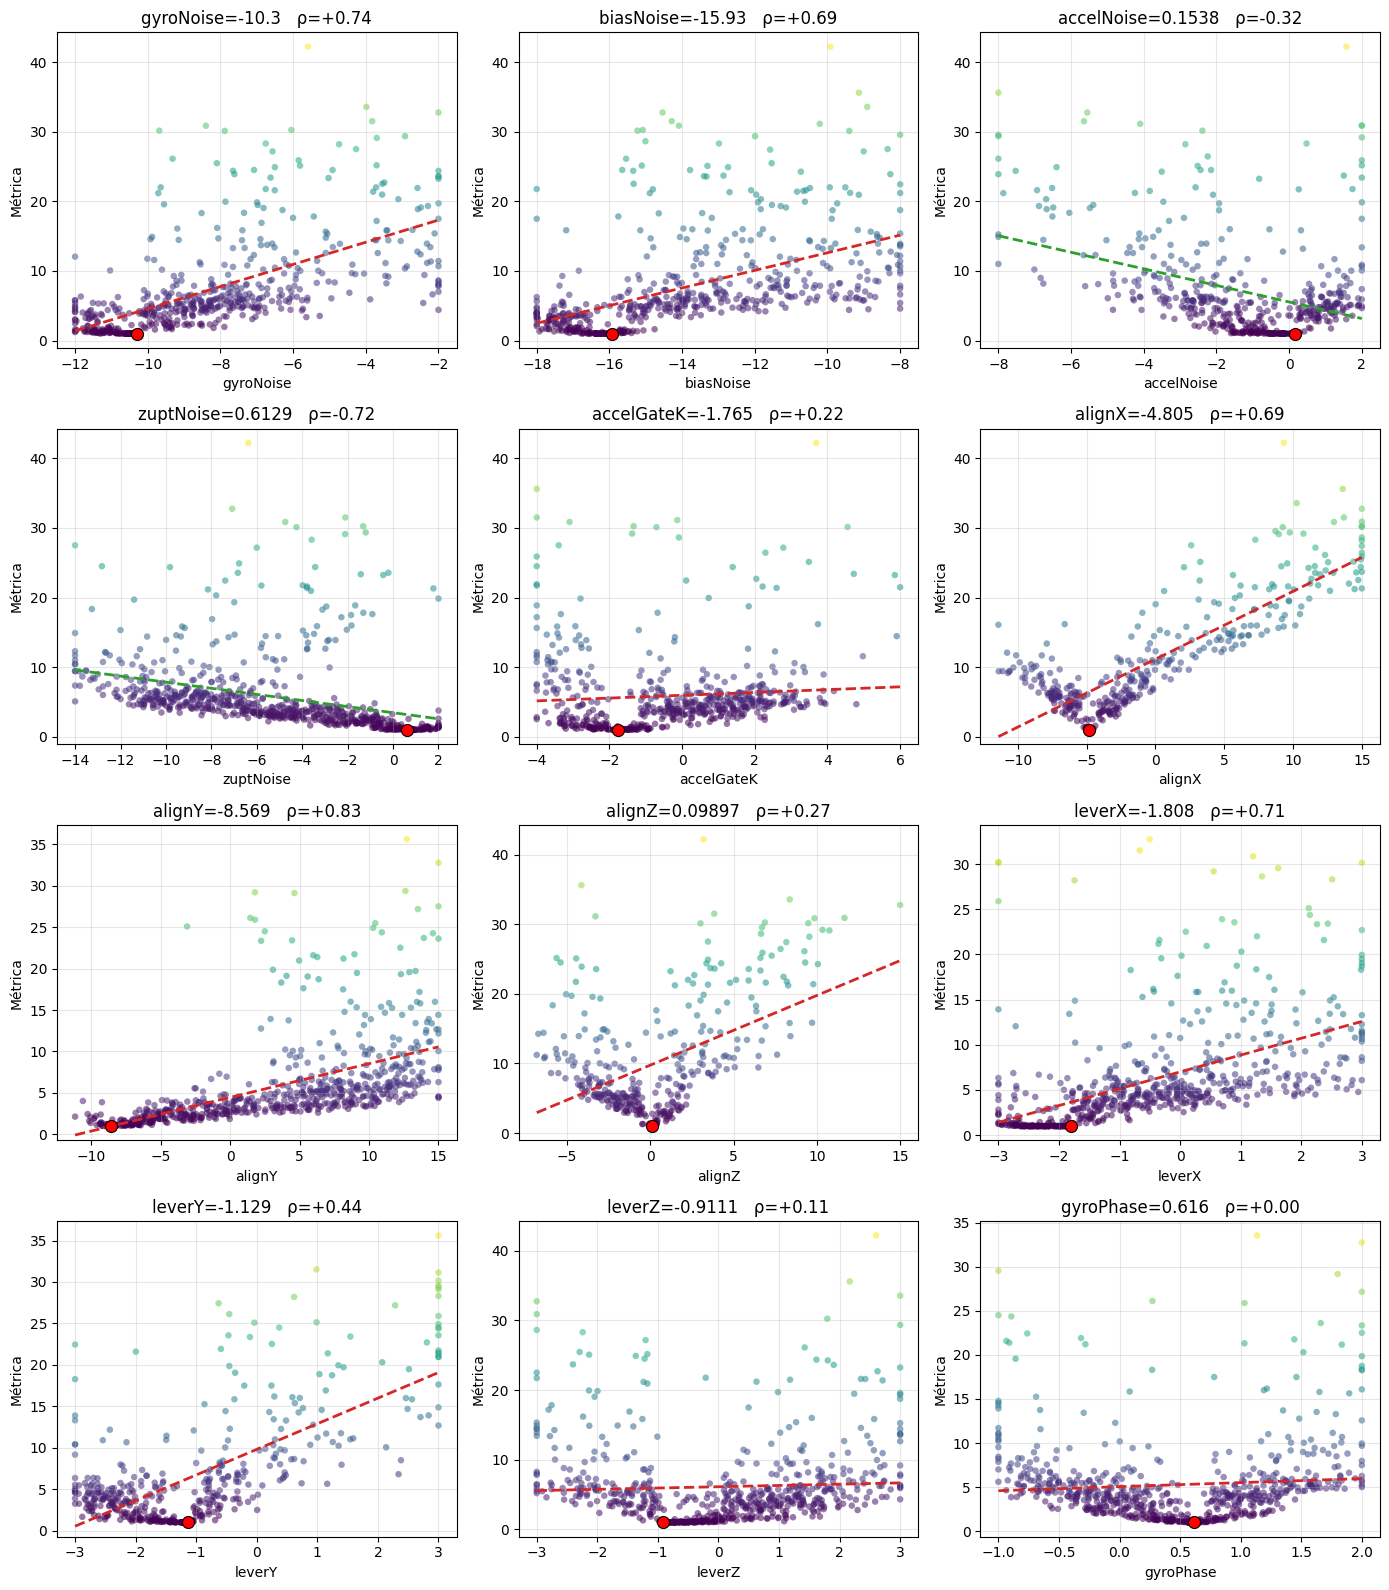

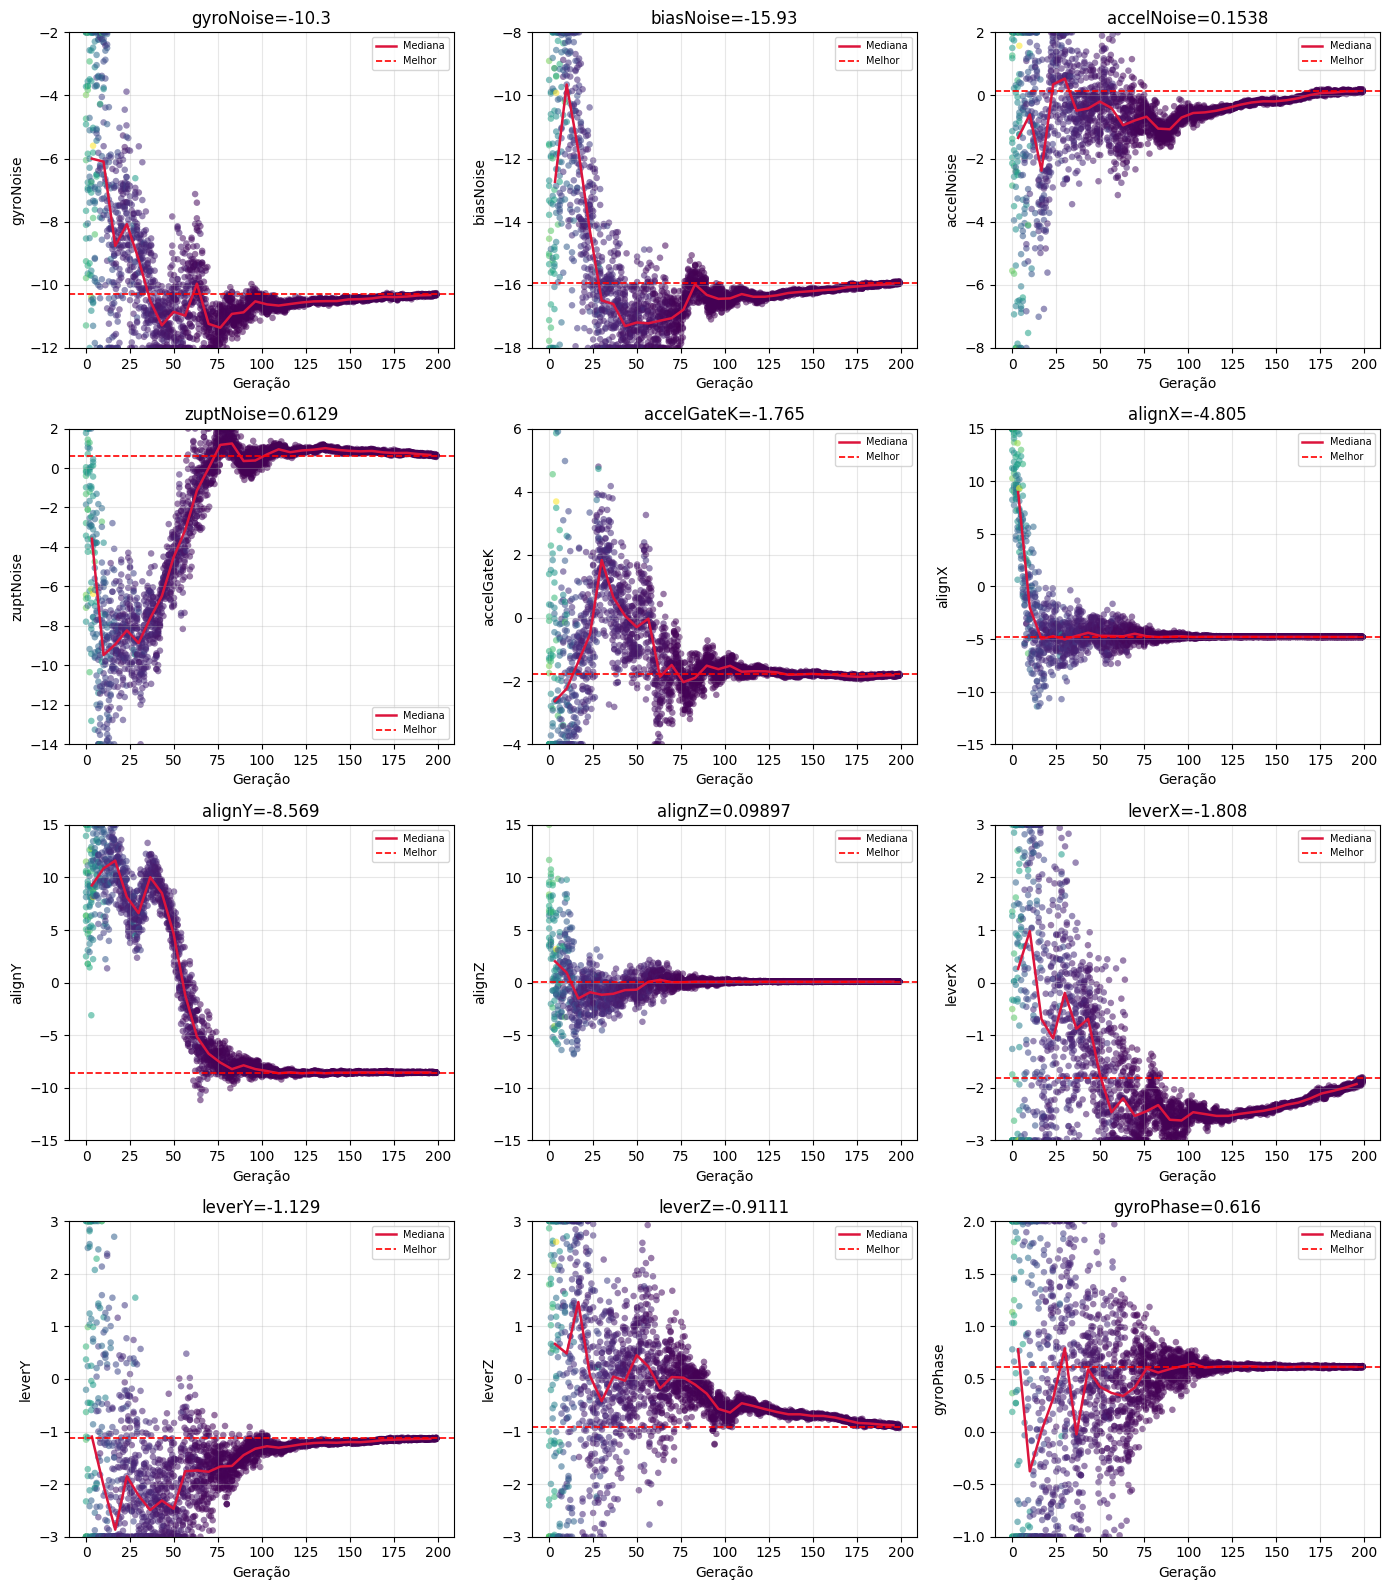

In [13]:
from Nature.index import NatureSelector

def objective(params):
    kf = KalmanFilter(df, xCols=xCols, yCols=yCols, params=params)
    kf.update()
    result = kf.get()
    return result['pitch']['rmse'] + result['roll']['rmse']


problem = {
    'objective': objective, 'maximize': False, 'seed': 42, 'verbose': True,
    'variables': {
        'gyroNoise':  {'bounds': (-12.0,  -2.0)},   # log10 (rad/s)^2/Hz   ARW do giro: 1e-12 a 1e-2
        'biasNoise':  {'bounds': (-18.0,  -8.0)},   # log10 (rad/s^2)^2/Hz random walk do bias
        'accelNoise': {'bounds': ( -8.0,   2.0)},   # log10 variancia do versor do acelerometro
        'zuptNoise':  {'bounds': (-14.0,   2.0)},   # log10 (rad/s)^2 do ZARU; o topo desliga a correcao
        'accelGateK': {'bounds': ( -4.0,   6.0)},   # log10 do ganho que infla R quando |a| foge de g
        'alignX':     {'bounds': (-15.0,  15.0)},   # graus, montagem do sensor no referencial da referencia
        'alignY':     {'bounds': (-15.0,  15.0)},
        'alignZ':     {'bounds': (-15.0,  15.0)},
        'leverX':     {'bounds': ( -3.0,   3.0)},   # metros, do centro de rotacao ate o sensor, no corpo
        'leverY':     {'bounds': ( -3.0,   3.0)},
        'leverZ':     {'bounds': ( -3.0,   3.0)},
        'gyroPhase':  {'bounds': ( -1.0,   2.0)},   # fase da taxa integrada: 0 retangular, 0.5 trapezoidal
    }
}
  
SEARCH = {'population': 15, 'generations': 200, 'workers': 8, 'backend': 'process'}
RUNS   = 1

model = NatureSelector('genetic', {**problem, **SEARCH}, n_gaussian=RUNS)
best, score = model.update()

print(f'soma de RMSE: {score:.4f} graus')
model.plotMetrics()
model.plotVariables('range')
model.plotVariables('temporal')

In [14]:
model.getBest()

{'algorithm': 'genetic',
 'f': 0.9885211182790234,
 'runs': 1,
 'stopped': 199,
 'variables': {'gyroNoise': -10.30021859836768,
  'biasNoise': -15.931678738884697,
  'accelNoise': 0.15382537124023585,
  'zuptNoise': 0.6128823959774189,
  'accelGateK': -1.7645609323488562,
  'alignX': -4.804581783583007,
  'alignY': -8.56860495676431,
  'alignZ': 0.09896944760814816,
  'leverX': -1.807919936375568,
  'leverY': -1.1289812414462423,
  'leverZ': -0.9110766339015416,
  'gyroPhase': 0.6159723468541011}}

# VISUALIZAÇÃO FINAL

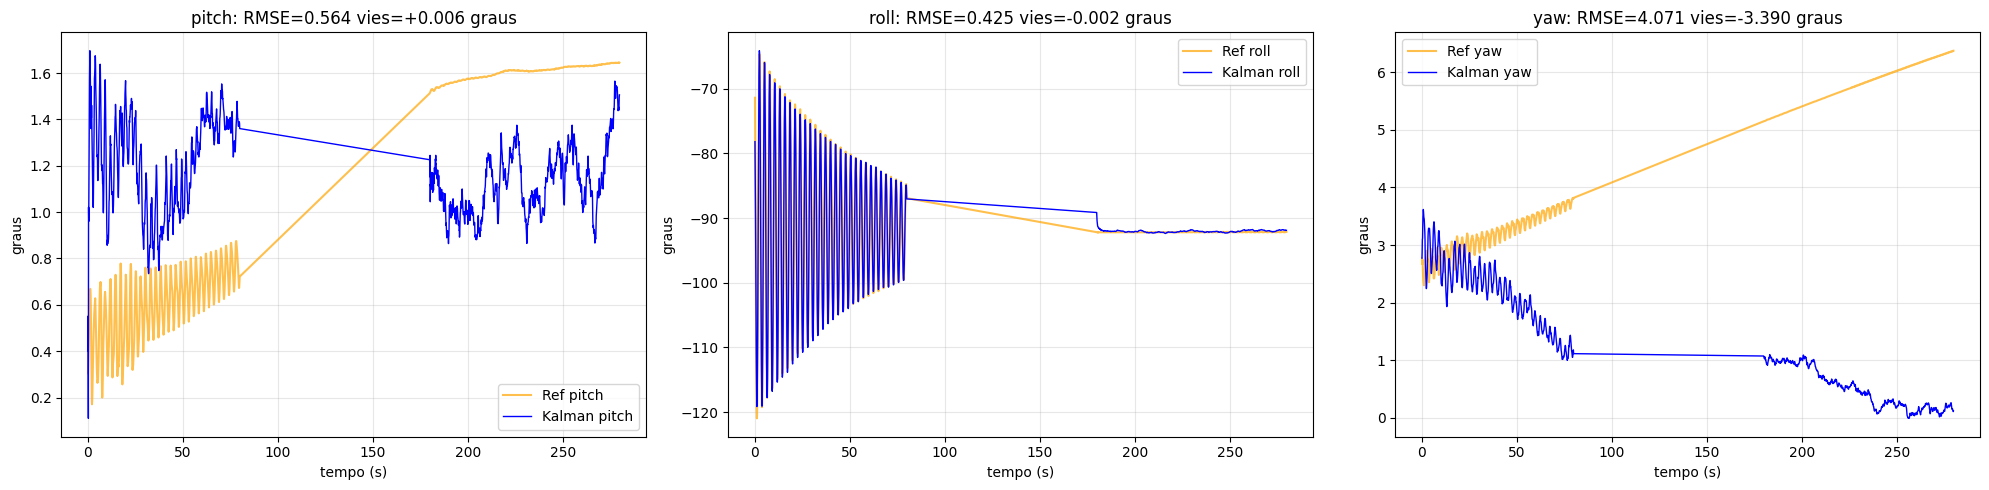

In [15]:
kf = KalmanFilter(df, xCols=xCols, yCols=yCols, params=best)
kf.update()
kf.plot()

# BACKUP DOS PARÂMETROS

In [16]:
os.makedirs('Backup', exist_ok=True)
saved  = [name for name in os.listdir('Backup') if name.startswith('model_')]    # O target.csv TEMPORÁRIO TAMBÉM MORA NO Backup
index  = len(saved) + 1

output = f'Backup/model_{index}'
os.makedirs(output, exist_ok=True)

results = {
    **model.getBest(),
    'search':  {**SEARCH, 'seed': problem['seed'], 'bounds': {k: v['bounds'] for k, v in problem['variables'].items()}},
    'metrics': kf.get(),
    'bias':    kf.bias.round(6).tolist(),
    'dataset': {'path': DATASET, 'samples': len(df), 'dt': float(dt), 'xCols': xCols, 'yCols': yCols}
}

pd.Series(results).to_json(f'{output}/info.json', indent=4)
print(output)
results

Backup/model_2


{'algorithm': 'genetic',
 'f': 0.9885211182790234,
 'runs': 1,
 'stopped': 199,
 'variables': {'gyroNoise': -10.30021859836768,
  'biasNoise': -15.931678738884697,
  'accelNoise': 0.15382537124023585,
  'zuptNoise': 0.6128823959774189,
  'accelGateK': -1.7645609323488562,
  'alignX': -4.804581783583007,
  'alignY': -8.56860495676431,
  'alignZ': 0.09896944760814816,
  'leverX': -1.807919936375568,
  'leverY': -1.1289812414462423,
  'leverZ': -0.9110766339015416,
  'gyroPhase': 0.6159723468541011},
 'search': {'population': 15,
  'generations': 200,
  'workers': 8,
  'backend': 'process',
  'seed': 42,
  'bounds': {'gyroNoise': (-12.0, -2.0),
   'biasNoise': (-18.0, -8.0),
   'accelNoise': (-8.0, 2.0),
   'zuptNoise': (-14.0, 2.0),
   'accelGateK': (-4.0, 6.0),
   'alignX': (-15.0, 15.0),
   'alignY': (-15.0, 15.0),
   'alignZ': (-15.0, 15.0),
   'leverX': (-3.0, 3.0),
   'leverY': (-3.0, 3.0),
   'leverZ': (-3.0, 3.0),
   'gyroPhase': (-1.0, 2.0)}},
 'metrics': {'pitch': {'rmse': 0.563

# SALVANDO O MODELO
- Ângulos do filtro ao lado dos da referência (`_ref`)

In [17]:
attitude = kf.result[['time', 'static']].copy()

for name in yCols:
    attitude[name]          = kf.result[f'kalman_{name}']
    attitude[f'{name}_ref'] = kf.result[name]

record = {
    'strategy': 'kalman_fusion',
    'backup':   f'Model/KalmanFusion/{output}',
    'targets':  yCols,
    'metrics':  kf.get()
}

os.makedirs(RESULTS, exist_ok=True)
attitude.to_csv(f'{RESULTS}/model.csv', index=None)
pd.Series(record).to_json(f'{RESULTS}/model.json', indent=4)
print(f'{RESULTS}/model.csv')
attitude

../../Dataset/test1/results/model.csv


,time,static,pitch,pitch_ref,roll,roll_ref,yaw,yaw_ref
0,0.0,False,0.399681,0.304871,-78.184789,-71.390541,2.771970,2.771970
1,0.1,False,0.551559,0.337243,-81.800890,-76.661753,2.896329,2.723841
2,0.2,False,0.110167,0.366750,-84.642271,-82.677810,3.095384,2.667691
3,0.3,False,1.021111,0.387721,-90.070954,-89.209529,3.118918,2.743322
4,0.4,False,0.959940,0.442381,-95.763063,-95.913135,3.313596,2.624720
...,...,...,...,...,...,...,...,...
1795,279.4,True,1.453468,1.644962,-91.862310,-92.131613,0.141376,6.371291
1796,279.5,True,1.439561,1.645535,-91.876657,-92.131613,0.130264,6.371291
1797,279.6,True,1.459397,1.644962,-91.885667,-92.131613,0.118031,6.371291
1798,279.7,True,1.497074,1.645535,-91.892366,-92.131613,0.104655,6.377020


# EXPORTANDO PARA O FIRMWARE
- Vão os parâmetros do filtro que acabou de rodar, já em unidade física: o `.h` não repete o log10 da busca
- O `config.h` do `processing` diz qual modelo o firmware compila; quem exportar por último é quem roda

In [18]:
FIRMWARE = '../../../Hardware/Embedded/Main/objects/processing'
STAMP    = f'{datetime.date.today():%d/%m/%Y}'

lever   = ', '.join(f'{value:.8f}f' for value in kf.lever)
heading = 'NAN' if kf.yaw0 is None else f'{kf.yaw0:.6f}f'

header = f'''#ifndef KALMAN_CONFIG_H
#define KALMAN_CONFIG_H

// GERADO POR Calibration/Model/KalmanFusion/1 - Model.ipynb EM {STAMP}
#define KALMAN_NAME        "kalman_fusion"
#define KALMAN_GRAVITY     {kf.g:.6f}f
#define KALMAN_GYRO_NOISE  {kf.gyroNoise:.8e}f     // (rad/s)^2/Hz do ARW do giro
#define KALMAN_BIAS_NOISE  {kf.biasNoise:.8e}f     // (rad/s^2)^2/Hz do random walk do bias
#define KALMAN_ACCEL_NOISE {kf.accelNoise:.8e}f    // variancia do versor do acelerometro
#define KALMAN_ZUPT_NOISE  {kf.zuptNoise:.8e}f     // (rad/s)^2 do ZARU
#define KALMAN_ACCEL_GATE  {kf.accelGateK:.8e}f    // ganho que infla R quando |a| foge de g
#define KALMAN_GYRO_PHASE  {kf.gyroPhase:.6f}f     // fase da taxa integrada: 0 retangular, 0.5 trapezoidal
#define KALMAN_ALIGN_X     {kf.align[0]:.6f}f      // graus, montagem do sensor no referencial da referencia
#define KALMAN_ALIGN_Y     {kf.align[1]:.6f}f
#define KALMAN_ALIGN_Z     {kf.align[2]:.6f}f
#define KALMAN_HEADING     {heading}    // proa inicial em graus; NAN pega a do sensor

static const float KALMAN_LEVER[3] = {{{lever}}};    // metros, do centro de rotacao ate o sensor, no corpo

#endif
'''

select = f'''#ifndef PROCESSING_CONFIG_H
#define PROCESSING_CONFIG_H
#include "models/kalman/index.h"

// GERADO POR Calibration/Model/KalmanFusion/1 - Model.ipynb EM {STAMP}
using ProcessingModel = KalmanModel;

#endif
'''

os.makedirs(f'{FIRMWARE}/models/kalman', exist_ok=True)
open(f'{FIRMWARE}/models/kalman/config.h', 'w').write(header)
open(f'{FIRMWARE}/config.h', 'w').write(select)

print(f'{FIRMWARE}/models/kalman/config.h')
print(header)

../../../Hardware/Embedded/Main/objects/processing/models/kalman/config.h
#ifndef KALMAN_CONFIG_H
#define KALMAN_CONFIG_H

// GERADO POR Calibration/Model/KalmanFusion/1 - Model.ipynb EM 23/09/2026
#define KALMAN_NAME        "kalman_fusion"
#define KALMAN_GRAVITY     9.810000f
#define KALMAN_GYRO_NOISE  5.00935029e-11f     // (rad/s)^2/Hz do ARW do giro
#define KALMAN_BIAS_NOISE  1.17036483e-16f     // (rad/s^2)^2/Hz do random walk do bias
#define KALMAN_ACCEL_NOISE 1.42503448e+00f    // variancia do versor do acelerometro
#define KALMAN_ZUPT_NOISE  4.10093038e+00f     // (rad/s)^2 do ZARU
#define KALMAN_ACCEL_GATE  1.71964605e-02f    // ganho que infla R quando |a| foge de g
#define KALMAN_GYRO_PHASE  0.615972f     // fase da taxa integrada: 0 retangular, 0.5 trapezoidal
#define KALMAN_ALIGN_X     -4.804582f      // graus, montagem do sensor no referencial da referencia
#define KALMAN_ALIGN_Y     -8.568605f
#define KALMAN_ALIGN_Z     0.098969f
#define KALMAN_HEADING     NAN    // proa